## One Hot Encoding

One-Hot Encoding converts categorical data with no natural order (nominal data) into multiple binary (0/1) columns — one new column per category — so the model doesn't accidentally assume a false ranking between categories.

**Core idea** Since nominal data (like City, Color, Gender) has no inherent order, you can't just assign 0, 1, 2, 3 like Ordinal Encoding does — that would falsely imply Chennai > Mumbai > Delhi. Instead, One-Hot Encoding creates a separate column for each category, marking 1 where that category applies and 0 everywhere else.

## String is converted into numbers

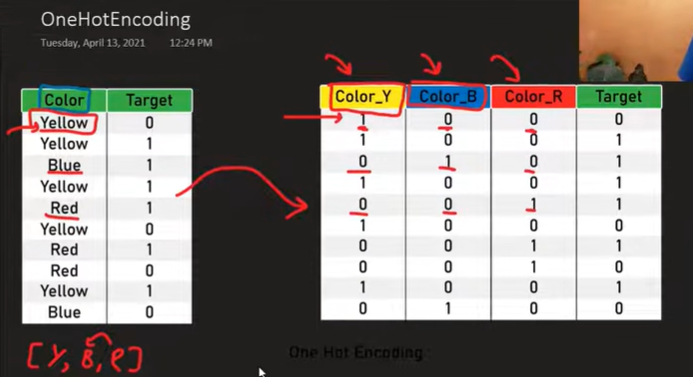


In [1]:
# We will not use first columns its a dummy columns trap. Then how we will know this is yellow?
# We will know that if its blue or red then its not yellow, if its not blue and not red then obviously its yellow

In [2]:
# What if 100s of values? yes we have to make 100s of columns if have 100 values.

In [3]:
# Reduce dimenions: Brand Nominal -> 40 Brands (Like car brands). if we make all columns process become slow so we make imp columns direct and make on other careory name others and set less imp in that

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('cars.csv')

In [6]:
df.sample(5)

,brand,km_driven,fuel,owner,selling_price
1582,Mahindra,35000,Diesel,First Owner,775000
2839,Ford,62000,Diesel,First Owner,700000
5161,Maruti,60000,Diesel,First Owner,500000
1640,Mahindra,100875,Diesel,First Owner,600000
2158,Hyundai,30000,Petrol,First Owner,400000


In [7]:
df['brand'].nunique()

32

In [8]:
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [9]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,0:4] , df.iloc[:,-1] , test_size=0.2, random_state=0)

In [12]:
x_test.head(5)

,brand,km_driven,fuel,owner
3558,Hyundai,40000,Diesel,First Owner
233,Mahindra,70000,Diesel,First Owner
7952,Maruti,5000,Petrol,First Owner
572,Maruti,120000,Petrol,Third Owner
6960,Lexus,20000,Petrol,First Owner


In [13]:
from sklearn.preprocessing import OneHotEncoder

In [14]:
ohe = OneHotEncoder()

In [15]:
ohe.fit_transform(x_train[['fuel','owner']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13004 stored elements and shape (6502, 9)>

In [16]:
x_train_new = ohe.fit_transform(x_train[['fuel','owner']]).toarray()

In [17]:
x_test_new = ohe.transform(x_test[['fuel','owner']]).toarray()

In [18]:
x_train[['brand', 'km_driven']].values

array([['Hyundai', 60000],
       ['Tata', 150000],
       ['Hyundai', 110000],
       ...,
       ['Hyundai', 90000],
       ['Volkswagen', 90000],
       ['Hyundai', 110000]], shape=(6502, 2), dtype=object)

In [19]:
np.hstack((x_train[['brand', 'km_driven']].values, x_train_new))

array([['Hyundai', 60000, 0.0, ..., 0.0, 0.0, 0.0],
       ['Tata', 150000, 0.0, ..., 0.0, 0.0, 1.0],
       ['Hyundai', 110000, 0.0, ..., 1.0, 0.0, 0.0],
       ...,
       ['Hyundai', 90000, 0.0, ..., 1.0, 0.0, 0.0],
       ['Volkswagen', 90000, 0.0, ..., 0.0, 0.0, 0.0],
       ['Hyundai', 110000, 0.0, ..., 0.0, 0.0, 0.0]],
      shape=(6502, 11), dtype=object)

In [20]:
np.hstack((x_train[['brand', 'km_driven']].values, x_train_new)).shape

(6502, 11)

In [21]:
# we can use one hot encoding using Pandas

pd.get_dummies(df,columns=['fuel', 'owner'] )

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


In [22]:
pd.get_dummies(df,columns=['fuel', 'owner'], drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


### OneHot coding with Top categories

In [27]:
counts = df['brand'].value_counts()

In [28]:
df['brand'].nunique()
threshold=100

In [29]:
repl = counts[counts <= threshold].index

In [30]:
pd.get_dummies(df['brand'].replace(repl, 'uncommon'))

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
0,False,False,False,False,False,False,True,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,False,False,False,False,True,False,False,False,False,False,False,False,False
8124,False,False,False,False,True,False,False,False,False,False,False,False,False
8125,False,False,False,False,False,False,True,False,False,False,False,False,False
8126,False,False,False,False,False,False,False,False,False,True,False,False,False
